# EDA BPS - Inflasi Indonesia

Notebook ini untuk Exploratory Data Analysis (EDA) data BPS (Badan Pusat Statistik)
- Analisis inflasi bulanan, tahunan, dan year-to-date
- Perbandingan inflasi antar provinsi
- Tren inflasi dari 2024-2026

In [1]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl
from datetime import datetime

# Set style untuk visualisasi
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Path ke data BPS
data_path = 'Data/BPS'

print(f"Working directory: {os.getcwd()}")
print(f"Data path: {data_path}")
print(f"Path exists: {os.path.exists(data_path)}")

Working directory: /Users/macos/Desktop/wrk/DQLAB Porto
Data path: Data/BPS
Path exists: True


In [2]:
# Get semua file Excel di folder BPS
bps_files = glob.glob(os.path.join(data_path, '*.xlsx'))
print(f"Jumlah file BPS: {len(bps_files)}")
print(f"\nNama file:")
for file in bps_files:
    print(f"  - {os.path.basename(file)}")

Jumlah file BPS: 9

Nama file:
  - Inflasi Bulanan (M-to-M) 38 Provinsi (2022=100), 2024.xlsx
  - Inflasi Tahunan (Y-on-Y) 38 Provinsi (2022=100), 2025.xlsx
  - Inflasi Tahun Kalender (Y-to-D) 38 Provinsi (2022=100), 2025.xlsx
  - Inflasi Tahun Kalender (Y-to-D) 38 Provinsi (2022=100), 2024.xlsx
  - Inflasi Tahunan (Y-on-Y) 38 Provinsi (2022=100), 2024.xlsx
  - Inflasi Bulanan (M-to-M) 38 Provinsi (2022=100), 2025.xlsx
  - Inflasi Bulanan (M-to-M) 38 Provinsi (2022=100), 2026.xlsx
  - Inflasi Tahunan (Y-on-Y) 38 Provinsi (2022=100), 2026.xlsx
  - Inflasi Tahun Kalender (Y-to-D) 38 Provinsi (2022=100), 2026.xlsx


## 1. Load dan Eksplorasi Data

In [3]:
# Fungsi untuk load file BPS dengan header yang benar
def load_bps_file(filepath):
    """Load BPS inflation file with proper header handling"""
    # Skip 3 baris pertama (title, year, blank), gunakan baris ke-4 sebagai header
    df = pd.read_excel(filepath, header=3)
    return df

# Test load satu file
test_file = bps_files[0]
print(f"Testing load: {os.path.basename(test_file)}")
df_test = load_bps_file(test_file)
print(f"Shape: {df_test.shape}")
print(f"\nKolom: {df_test.columns.tolist()}")
print(f"\nFirst 5 rows:")
df_test.head()

Testing load: Inflasi Bulanan (M-to-M) 38 Provinsi (2022=100), 2024.xlsx
Shape: (39, 14)

Kolom: ['Unnamed: 0', 'Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni', 'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember', 'Tahunan']

First 5 rows:


,Unnamed: 0,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember,Tahunan
0,PROV ACEH,0.42,0.71,0.48,0.05,0.15,0.03,-0.11,0.10,-0.52,-0.08,0.37,0.57,-
1,PROV SUMATERA UTARA,0.40,0.41,0.72,-0.04,0.48,-0.33,-0.82,-0.14,-0.21,0.13,0.54,0.98,-
2,PROV SUMATERA BARAT,-0.32,1.17,0.64,-0.30,0.51,0.14,-1.07,-0.16,-0.44,0.11,0.27,0.35,-
3,PROV RIAU,0.11,0.59,0.72,0.05,0.30,-0.22,-0.80,-0.27,-0.33,0.06,0.43,0.62,-
4,PROV JAMBI,0.83,0.13,0.54,0.18,0.19,-0.13,-0.82,-0.01,-0.17,0.03,0.21,0.46,-


In [4]:
# Load semua file dan gabungkan
all_data = []

for file in bps_files:
    try:
        filename = os.path.basename(file)
        print(f"Loading: {filename}")
        
        df = load_bps_file(file)
        
        # Ekstrak informasi dari filename
        # Format: "Inflasi Bulanan (M-to-M) 38 Provinsi (2022=100), 2024.xlsx"
        parts = filename.replace('.xlsx', '').split(', ')
        year = parts[-1]  # Tahun
        type_name = parts[0]  # Tipe inflasi
        
        df['Tahun'] = year
        df['Tipe_Inflasi'] = type_name
        
        all_data.append(df)
        print(f"  ✓ Berhasil - Shape: {df.shape}")
    except Exception as e:
        print(f"  ✗ Error: {e}")

print(f"\nTotal file berhasil dimuat: {len(all_data)}")

Loading: Inflasi Bulanan (M-to-M) 38 Provinsi (2022=100), 2024.xlsx
  ✓ Berhasil - Shape: (39, 16)
Loading: Inflasi Tahunan (Y-on-Y) 38 Provinsi (2022=100), 2025.xlsx
  ✓ Berhasil - Shape: (39, 16)
Loading: Inflasi Tahun Kalender (Y-to-D) 38 Provinsi (2022=100), 2025.xlsx
  ✓ Berhasil - Shape: (39, 16)
Loading: Inflasi Tahun Kalender (Y-to-D) 38 Provinsi (2022=100), 2024.xlsx
  ✓ Berhasil - Shape: (39, 16)
Loading: Inflasi Tahunan (Y-on-Y) 38 Provinsi (2022=100), 2024.xlsx
  ✓ Berhasil - Shape: (39, 16)
Loading: Inflasi Bulanan (M-to-M) 38 Provinsi (2022=100), 2025.xlsx
  ✓ Berhasil - Shape: (39, 16)
Loading: Inflasi Bulanan (M-to-M) 38 Provinsi (2022=100), 2026.xlsx
  ✓ Berhasil - Shape: (39, 16)
Loading: Inflasi Tahunan (Y-on-Y) 38 Provinsi (2022=100), 2026.xlsx
  ✓ Berhasil - Shape: (39, 16)
Loading: Inflasi Tahun Kalender (Y-to-D) 38 Provinsi (2022=100), 2026.xlsx
  ✓ Berhasil - Shape: (39, 16)

Total file berhasil dimuat: 9


In [5]:
# Concatenate semua data
if len(all_data) > 0:
    df_combined = pd.concat(all_data, ignore_index=True)
    print(f"Shape data gabungan: {df_combined.shape}")
    print(f"\nKolom: {df_combined.columns.tolist()}")
else:
    print("ERROR: Tidak ada data yang berhasil dimuat!")

Shape data gabungan: (351, 16)

Kolom: ['Unnamed: 0', 'Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni', 'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember', 'Tahunan', 'Tahun', 'Tipe_Inflasi']


In [6]:
# Tampilkan data gabungan
df_combined

,Unnamed: 0,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember,Tahunan,Tahun,Tipe_Inflasi
0,PROV ACEH,0.42,0.71,0.48,0.05,0.15,0.03,-0.11,0.1,-0.52,-0.08,0.37,0.57,-,2024,Inflasi Bulanan (M-to-M) 38 Provinsi (2022=100)
1,PROV SUMATERA UTARA,0.40,0.41,0.72,-0.04,0.48,-0.33,-0.82,-0.14,-0.21,0.13,0.54,0.98,-,2024,Inflasi Bulanan (M-to-M) 38 Provinsi (2022=100)
2,PROV SUMATERA BARAT,-0.32,1.17,0.64,-0.3,0.51,0.14,-1.07,-0.16,-0.44,0.11,0.27,0.35,-,2024,Inflasi Bulanan (M-to-M) 38 Provinsi (2022=100)
3,PROV RIAU,0.11,0.59,0.72,0.05,0.3,-0.22,-0.8,-0.27,-0.33,0.06,0.43,0.62,-,2024,Inflasi Bulanan (M-to-M) 38 Provinsi (2022=100)
4,PROV JAMBI,0.83,0.13,0.54,0.18,0.19,-0.13,-0.82,-0.01,-0.17,0.03,0.21,0.46,-,2024,Inflasi Bulanan (M-to-M) 38 Provinsi (2022=100)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346,PAPUA,-0.36,-0.30,0.41,-,-,-,-,-,-,-,-,-,-,2026,Inflasi Tahun Kalender (Y-to-D) 38 Provinsi (2...
347,PAPUA SELATAN,1.06,1.66,2.02,-,-,-,-,-,-,-,-,-,-,2026,Inflasi Tahun Kalender (Y-to-D) 38 Provinsi (2...
348,PAPUA TENGAH,-0.29,-0.32,-0.05,-,-,-,-,-,-,-,-,-,-,2026,Inflasi Tahun Kalender (Y-to-D) 38 Provinsi (2...
349,PAPUA PEGUNUNGAN,-0.05,0.43,3.02,-,-,-,-,-,-,-,-,-,-,2026,Inflasi Tahun Kalender (Y-to-D) 38 Provinsi (2...


## 2. Data Cleaning dan Preprocessing

In [7]:
# Cek nama kolom provinsi (biasanya kolom pertama)
province_col = df_combined.columns[0]
print(f"Kolom provinsi: {province_col}")
print(f"\nProvinsi unik: {df_combined[province_col].nunique()}")
print(f"\nTipe Inflasi unik: {df_combined['Tipe_Inflasi'].unique()}")
print(f"\nTahun unik: {df_combined['Tahun'].unique()}")

Kolom provinsi: Unnamed: 0

Provinsi unik: 77

Tipe Inflasi unik: ['Inflasi Bulanan (M-to-M) 38 Provinsi (2022=100)'
 'Inflasi Tahunan (Y-on-Y) 38 Provinsi (2022=100)'
 'Inflasi Tahun Kalender (Y-to-D) 38 Provinsi (2022=100)']

Tahun unik: ['2024' '2025' '2026']


In [8]:
# Rename kolom provinsi
df_combined = df_combined.rename(columns={province_col: 'Provinsi'})

# Bersihkan nama provinsi (hapus 'PROV ' prefix)
df_combined['Provinsi'] = df_combined['Provinsi'].str.replace('PROV ', '').str.strip()

print("Provinsi setelah cleaning:")
print(df_combined['Provinsi'].unique()[:10])

Provinsi setelah cleaning:
['ACEH' 'SUMATERA UTARA' 'SUMATERA BARAT' 'RIAU' 'JAMBI'
 'SUMATERA SELATAN' 'BENGKULU' 'LAMPUNG' 'KEPULAUAN BANGKA BELITUNG'
 'KEPULAUAN RIAU']


/var/folders/fv/brbgpb2s06l4qqjx2s4cc9t40000gn/T/ipykernel_52530/2891099337.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_combined['Provinsi'] = df_combined['Provinsi'].str.replace('PROV ', '').str.strip()


In [9]:
# Reshape data dari wide ke long format
# Kolom bulan (semua kolom kecuali Provinsi, Tahun, Tipe_Inflasi)
month_columns = [col for col in df_combined.columns if col not in ['Provinsi', 'Tahun', 'Tipe_Inflasi']]
print(f"Kolom bulan: {len(month_columns)}")
print(month_columns)

Kolom bulan: 13
['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni', 'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember', 'Tahunan']


In [10]:
# Melting data untuk format long
id_vars = ['Provinsi', 'Tahun', 'Tipe_Inflasi']
df_long = df_combined.melt(
    id_vars=id_vars,
    value_vars=month_columns,
    var_name='Bulan',
    value_name='Inflasi'
)

print(f"Shape data long format: {df_long.shape}")
df_long.head()

Shape data long format: (4563, 5)


,Provinsi,Tahun,Tipe_Inflasi,Bulan,Inflasi
0,ACEH,2024,Inflasi Bulanan (M-to-M) 38 Provinsi (2022=100),Januari,0.42
1,SUMATERA UTARA,2024,Inflasi Bulanan (M-to-M) 38 Provinsi (2022=100),Januari,0.4
2,SUMATERA BARAT,2024,Inflasi Bulanan (M-to-M) 38 Provinsi (2022=100),Januari,-0.32
3,RIAU,2024,Inflasi Bulanan (M-to-M) 38 Provinsi (2022=100),Januari,0.11
4,JAMBI,2024,Inflasi Bulanan (M-to-M) 38 Provinsi (2022=100),Januari,0.83


In [11]:
# Convert inflasi ke numeric
df_long['Inflasi'] = pd.to_numeric(df_long['Inflasi'], errors='coerce')
df_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4563 entries, 0 to 4562
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Provinsi      4563 non-null   object 
 1   Tahun         4563 non-null   object 
 2   Tipe_Inflasi  4563 non-null   object 
 3   Bulan         4563 non-null   object 
 4   Inflasi       3159 non-null   float64
dtypes: float64(1), object(4)
memory usage: 178.4+ KB


/var/folders/fv/brbgpb2s06l4qqjx2s4cc9t40000gn/T/ipykernel_52530/1680737731.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_long['Inflasi'] = pd.to_numeric(df_long['Inflasi'], errors='coerce')


## 3. Exploratory Data Analysis

In [12]:
# Statistik deskriptif
df_long.describe()

,Inflasi
count,3159.000000
mean,1.216619
std,1.411623
min,-3.670000
25%,0.170000
50%,0.980000
75%,2.125000
max,8.050000


In [13]:
# Cek missing values
print("Missing Values:")
df_long.isnull().sum()

Missing Values:


Provinsi           0
Tahun              0
Tipe_Inflasi       0
Bulan              0
Inflasi         1404
dtype: int64

In [14]:
# Rata-rata inflasi per tipe
avg_by_type = df_long.groupby('Tipe_Inflasi')['Inflasi'].mean().sort_values(ascending=False)
print("Rata-rata Inflasi per Tipe:")
print(avg_by_type)

Rata-rata Inflasi per Tipe:
Tipe_Inflasi
Inflasi Tahunan (Y-on-Y) 38 Provinsi (2022=100)           2.407920
Inflasi Tahun Kalender (Y-to-D) 38 Provinsi (2022=100)    1.038386
Inflasi Bulanan (M-to-M) 38 Provinsi (2022=100)           0.203552
Name: Inflasi, dtype: float64


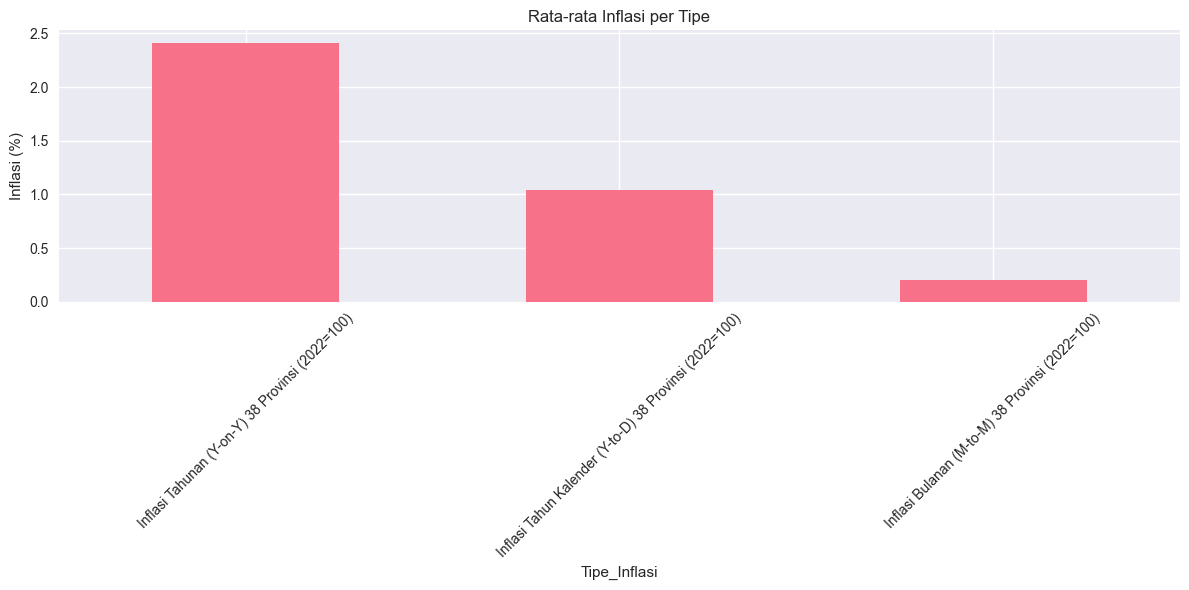

In [15]:
# Visualisasi rata-rata inflasi per tipe
plt.figure(figsize=(12, 6))
avg_by_type.plot(kind='bar')
plt.xticks(rotation=45)
plt.title('Rata-rata Inflasi per Tipe')
plt.ylabel('Inflasi (%)')
plt.tight_layout()
plt.show()

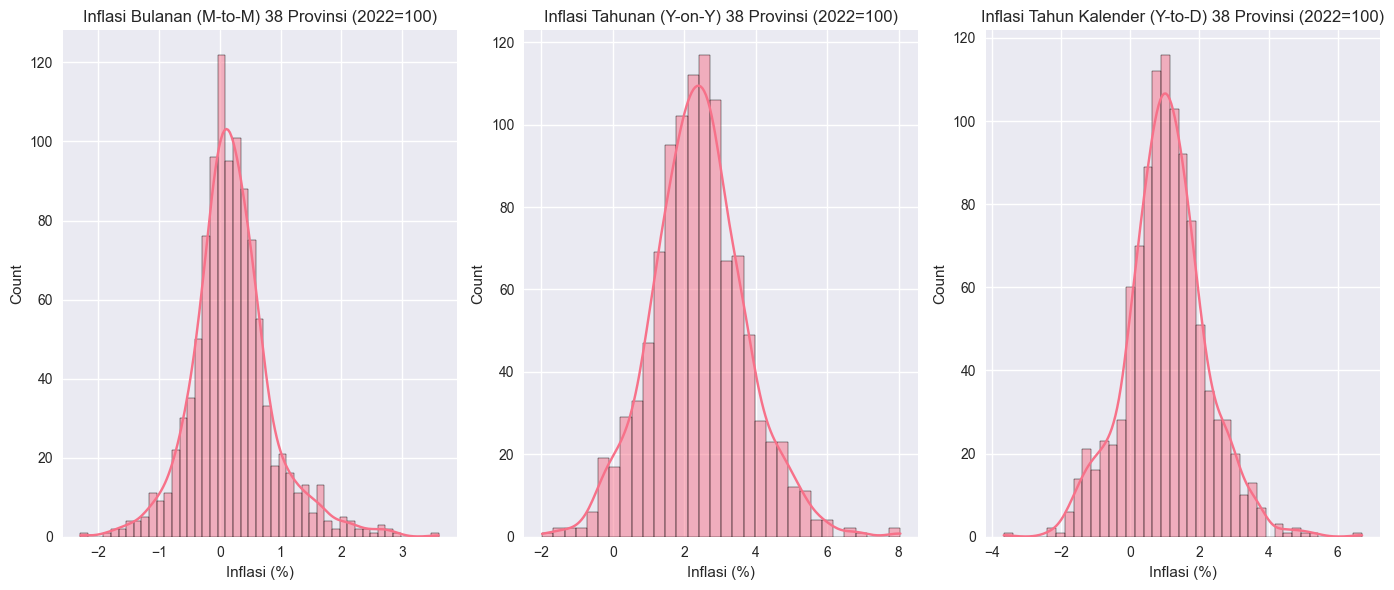

In [16]:
# Distribusi inflasi per tipe
plt.figure(figsize=(14, 6))
for i, tipe in enumerate(df_long['Tipe_Inflasi'].unique()):
    plt.subplot(1, 3, i+1)
    df_type = df_long[df_long['Tipe_Inflasi'] == tipe]
    sns.histplot(df_type['Inflasi'].dropna(), kde=True)
    plt.title(tipe)
    plt.xlabel('Inflasi (%)')
plt.tight_layout()
plt.show()

/var/folders/fv/brbgpb2s06l4qqjx2s4cc9t40000gn/T/ipykernel_52530/2168858857.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  monthly_data['Bulan'] = pd.Categorical(monthly_data['Bulan'], categories=month_order, ordered=True)
/var/folders/

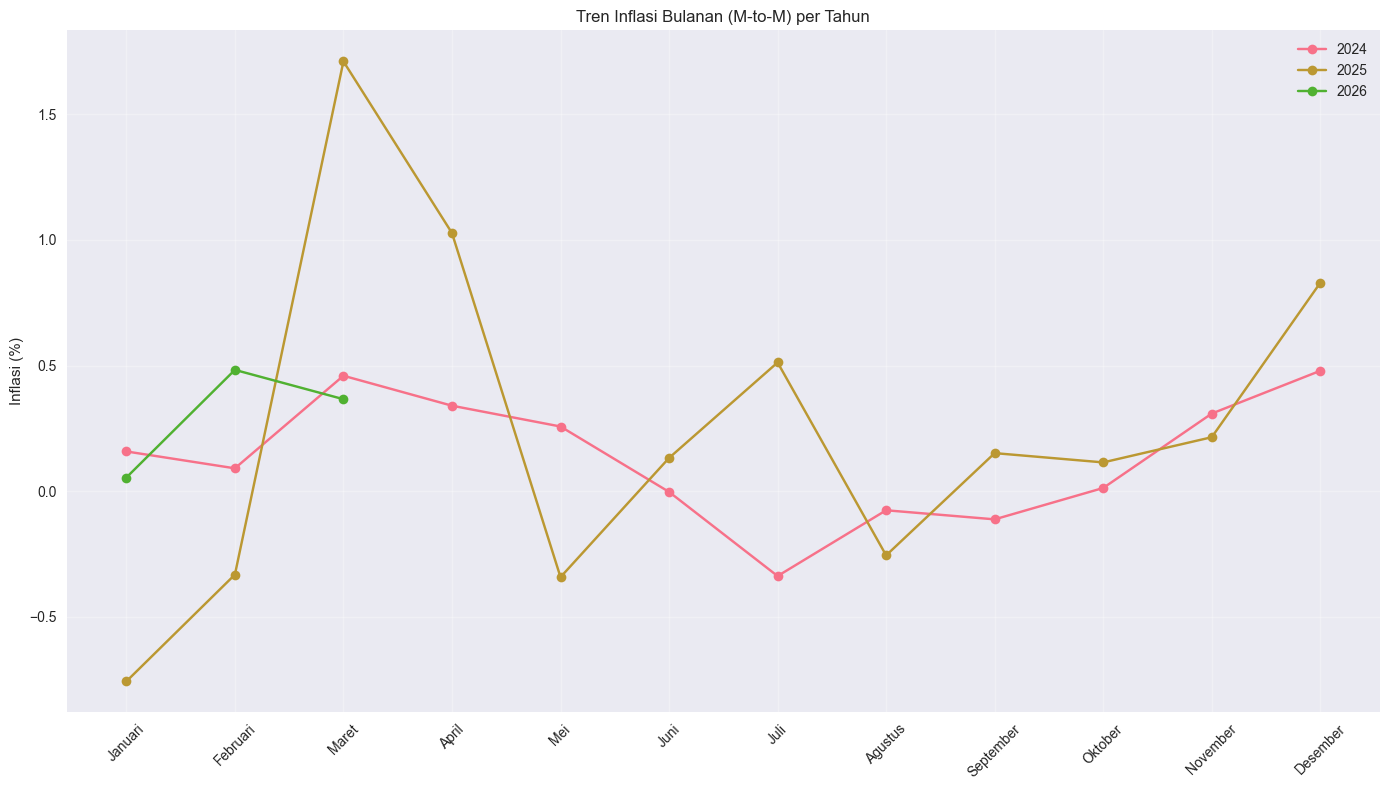

In [17]:
# Tren inflasi bulanan (M-to-M) per tahun
monthly_data = df_long[df_long['Tipe_Inflasi'] == 'Inflasi Bulanan (M-to-M) 38 Provinsi (2022=100)'].copy()

# Urutkan bulan
month_order = ['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni', 
               'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember']
monthly_data['Bulan'] = pd.Categorical(monthly_data['Bulan'], categories=month_order, ordered=True)

plt.figure(figsize=(14, 8))
for year in monthly_data['Tahun'].unique():
    df_year = monthly_data[monthly_data['Tahun'] == year]
    monthly_avg = df_year.groupby('Bulan')['Inflasi'].mean()
    plt.plot(monthly_avg.index, monthly_avg.values, marker='o', label=year)

plt.xticks(rotation=45)
plt.title('Tren Inflasi Bulanan (M-to-M) per Tahun')
plt.ylabel('Inflasi (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/fv/brbgpb2s06l4qqjx2s4cc9t40000gn/T/ipykernel_52530/3718683997.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = heatmap_data.pivot_table(


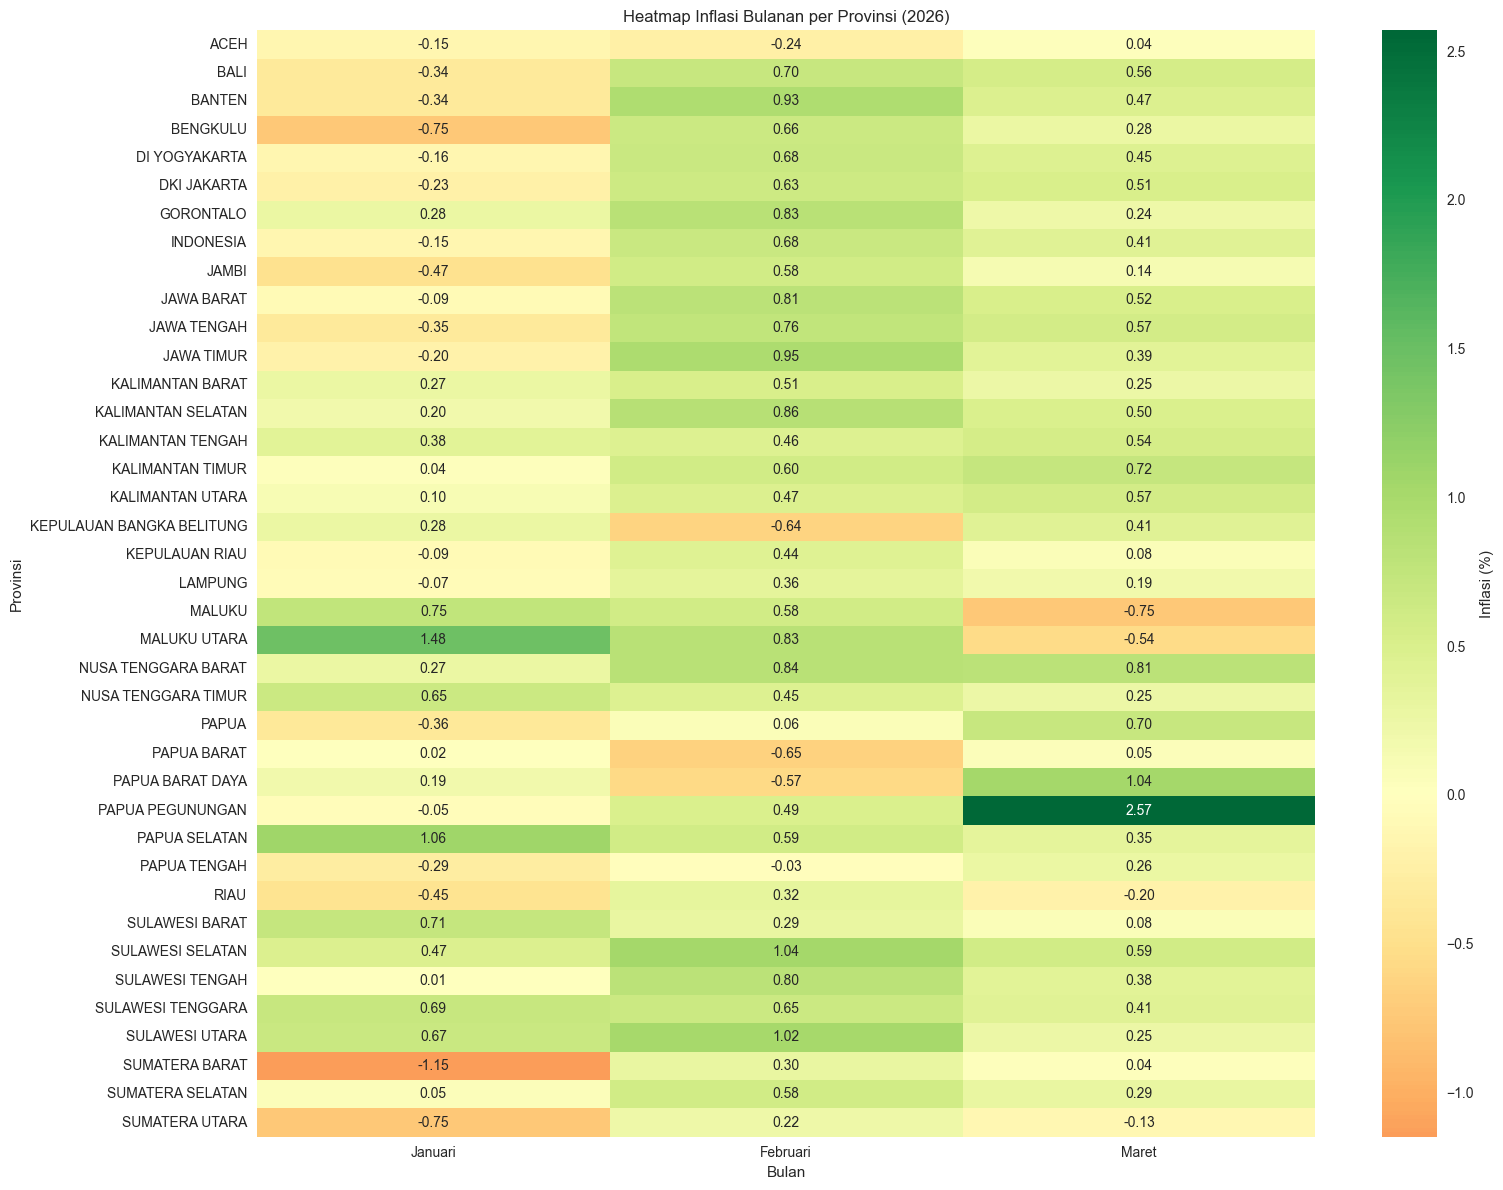

In [19]:
# Heatmap inflasi per provinsi dan bulan (untuk inflasi bulanan 2024)
heatmap_data = monthly_data[monthly_data['Tahun'] == '2026'].copy()
pivot_table = heatmap_data.pivot_table(
    values='Inflasi',
    index='Provinsi',
    columns='Bulan',
    aggfunc='mean'
)

plt.figure(figsize=(16, 12))
sns.heatmap(pivot_table, annot=True, fmt='.2f', cmap='RdYlGn', center=0, 
            cbar_kws={'label': 'Inflasi (%)'})
plt.title('Heatmap Inflasi Bulanan per Provinsi (2026)')
plt.tight_layout()
plt.show()

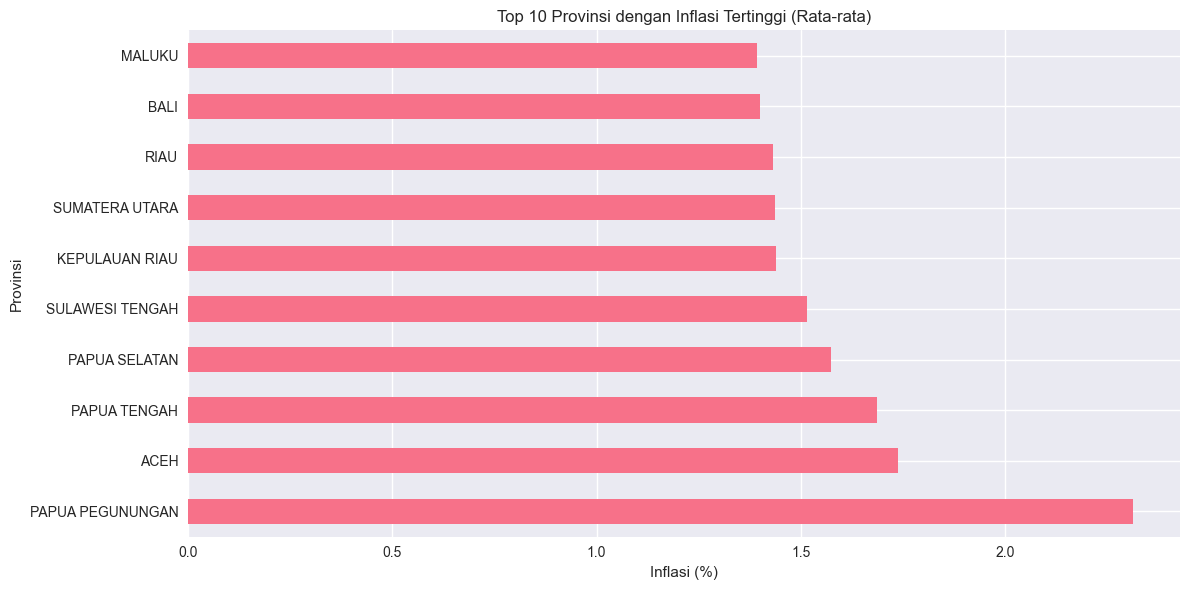

In [19]:
# Top 10 provinsi dengan inflasi tertinggi (rata-rata)
top_inflation = df_long.groupby('Provinsi')['Inflasi'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
top_inflation.plot(kind='barh')
plt.title('Top 10 Provinsi dengan Inflasi Tertinggi (Rata-rata)')
plt.xlabel('Inflasi (%)')
plt.tight_layout()
plt.show()

In [21]:
# Melting data untuk mendapatkan year dan month
id_vars = ['Provinsi', 'Tipe_Inflasi']
value_vars = [col for col in df_combined.columns if col not in ['Provinsi', 'Tahun', 'Tipe_Inflasi']]

df_melt = df_combined.melt(
    id_vars=id_vars + ['Tahun'],
    value_vars=value_vars,
    var_name='Bulan',
    value_name='Inflasi'
)

# Mapping nama bulan ke angka
month_map = {
    'Januari': '01', 'Februari': '02', 'Maret': '03', 'April': '04',
    'Mei': '05', 'Juni': '06', 'Juli': '07', 'Agustus': '08',
    'September': '09', 'Oktober': '10', 'November': '11', 'Desember': '12'
}

df_melt['Bulan_Num'] = df_melt['Bulan'].map(month_map)
df_melt['Date'] = df_melt['Tahun'] + '-' + df_melt['Bulan_Num']

# Pivot ke wide format dengan datetime column names
df_wide_datetime = df_melt.pivot_table(
    index=['Provinsi', 'Tipe_Inflasi'],
    columns='Date',
    values='Inflasi',
    aggfunc='first'
).reset_index()

print(f"Shape wide format datetime: {df_wide_datetime.shape}")
print(f"\nColumns: {df_wide_datetime.columns.tolist()}")
df_wide_datetime.head()

Shape wide format datetime: (117, 38)

Columns: ['Provinsi', 'Tipe_Inflasi', '2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06', '2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12', '2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04', '2026-05', '2026-06', '2026-07', '2026-08', '2026-09', '2026-10', '2026-11', '2026-12']


/var/folders/fv/brbgpb2s06l4qqjx2s4cc9t40000gn/T/ipykernel_52530/1788525827.py:19: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_melt['Bulan_Num'] = df_melt['Bulan'].map(month_map)
/var/folders/fv/brbgpb2s06l4qqjx2s4cc9t40000gn/T/ipykerne

Date,Provinsi,Tipe_Inflasi,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,...,2026-03,2026-04,2026-05,2026-06,2026-07,2026-08,2026-09,2026-10,2026-11,2026-12
0,ACEH,Inflasi Bulanan (M-to-M) 38 Provinsi (2022=100),0.42,0.71,0.48,0.05,0.15,0.03,-0.11,0.1,...,0.04,-,-,-,-,-,-,-,-,-
1,ACEH,Inflasi Tahun Kalender (Y-to-D) 38 Provinsi (2...,0.42,1.13,1.62,1.67,1.82,1.85,1.73,1.84,...,-0.34,-,-,-,-,-,-,-,-,-
2,ACEH,Inflasi Tahunan (Y-on-Y) 38 Provinsi (2022=100),2.12,2.33,3.25,3.14,3.32,3.09,2.51,2.29,...,5.31,-,-,-,-,-,-,-,-,-
3,BALI,Inflasi Bulanan (M-to-M) 38 Provinsi (2022=100),-0.09,0.61,0.93,0.32,-0.1,-0.55,0.1,0.1,...,0.56,-,-,-,-,-,-,-,-,-
4,BALI,Inflasi Tahun Kalender (Y-to-D) 38 Provinsi (2...,-0.09,0.52,1.46,1.78,1.68,1.12,1.22,1.33,...,0.91,-,-,-,-,-,-,-,-,-


In [24]:
# Export wide format dengan datetime column names
df_wide_datetime.to_excel('BPS_Inflasi_WideFormat_Datetime.xlsx', index=False, engine='openpyxl')
print("Data wide format datetime berhasil diexport ke: BPS_Inflasi_WideFormat_Datetime.xlsx")

Data wide format datetime berhasil diexport ke: BPS_Inflasi_WideFormat_Datetime.xlsx


## 4. Export Data

In [21]:
# Export data long format
df_long.to_csv('BPS_Inflasi_LongFormat.csv', index=False)
print("Data berhasil diexport ke: BPS_Inflasi_LongFormat.csv")

Data berhasil diexport ke: BPS_Inflasi_LongFormat.csv


In [22]:
# Export data wide format
df_combined.to_csv('BPS_Inflasi_WideFormat.csv', index=False)
print("Data wide format berhasil diexport ke: BPS_Inflasi_WideFormat.csv")

Data wide format berhasil diexport ke: BPS_Inflasi_WideFormat.csv


## 5. Kesimpulan

### Ringkasan:
1. **Data Loading**: Berhasil load {len(bps_files)} file BPS
2. **Tipe Inflasi**: {df_long['Tipe_Inflasi'].nunique()} tipe (Bulanan, Tahun Kalender, Tahunan)
3. **Periode**: Data mencakup tahun 2024-2026
4. **Provinsi**: {df_long['Provinsi'].nunique()} provinsi

### Insight Utama:
- Tipe inflasi dengan rata-rata tertinggi: {avg_by_type.index[0]}
- Tipe inflasi dengan rata-rata terendah: {avg_by_type.index[-1]}
- Provinsi dengan inflasi tertinggi: {top_inflation.index[0]}
- Provinsi dengan inflasi terendah: {bottom_inflation.index[0]}